El objetivo es predecir si un paciente tiene o no diabetes en base a
medidas diagnósticas.

**Variable objetivo:** Outcome (0 = no diabetes, 1 = diabetes)
**Tipo de problema:** Clasificación binaria

Pasos:
1. Carga del conjunto de datos
2. Exploración y limpieza de datos
3. Análisis univariante
4. Análisis multivariante
5. Ingeniería de características
6. Selección de características
7. Modelo de árbol de decisión (distintas funciones de pureza)
8. Optimización con Grid Search
9. Guardado del modelo


## 00 Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             roc_auc_score, roc_curve)
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## Paso 1: Carga del conjunto de datos

In [3]:


TARGET = 'Outcome'

url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 768  |  Columnas: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Paso 2: Exploración y limpieza de datos

### 2.1 Tipos de datos y estructura


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().round(2)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### 2.2 Valores nulos

In [6]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
reporte = pd.DataFrame({"Nulos": nulos, "Porcentaje %": pct})
reporte_con_nulos = reporte[reporte["Nulos"] > 0]

if len(reporte_con_nulos) == 0:
    print("✅ El dataset no tiene valores nulos explícitos.")
else:
    print(reporte_con_nulos)


✅ El dataset no tiene valores nulos explícitos.


En este dataset los valores 0 en columnas como Glucose, BloodPressure, SkinThickness, Insulin y BMI
significan datos faltantes que fueron codificados como cero.



In [7]:
# Columnas donde 0 
cols_cero_invalido = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Cantidad de ceros inválidos por columna:")
for col in cols_cero_invalido:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col}: {n} ceros ({pct:.1f}%)")


Cantidad de ceros inválidos por columna:
  Glucose: 5 ceros (0.7%)
  BloodPressure: 35 ceros (4.6%)
  SkinThickness: 227 ceros (29.6%)
  Insulin: 374 ceros (48.7%)
  BMI: 11 ceros (1.4%)


In [8]:
# Reemplazamos los ceros inválidos con la mediana de cada columna
for col in cols_cero_invalido:
    mediana = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, mediana)
    
print("Ceros inválidos reemplazados con la mediana de cada columna.")
df[cols_cero_invalido].describe().round(2)


Ceros inválidos reemplazados con la mediana de cada columna.


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.00,768.00,768.00,768.00,768.00
mean,121.66,72.39,29.11,140.67,32.46
std,30.44,12.10,8.79,86.38,6.88
min,44.00,24.00,7.00,14.00,18.20
25%,99.75,64.00,25.00,121.50,27.50
50%,117.00,72.00,29.00,125.00,32.30
75%,140.25,80.00,32.00,127.25,36.60
max,199.00,122.00,99.00,846.00,67.10


### 2.3 Duplicados

In [9]:
dupl = df.duplicated().sum()
print(f"Filas duplicadas: {dupl}")
if dupl > 0:
    df.drop_duplicates(inplace=True)
    print(f"Eliminadas. Nueva forma: {df.shape}")


Filas duplicadas: 0


## Paso 3: Análisis univariante

### 3.1 Variable objetivo — Outcome


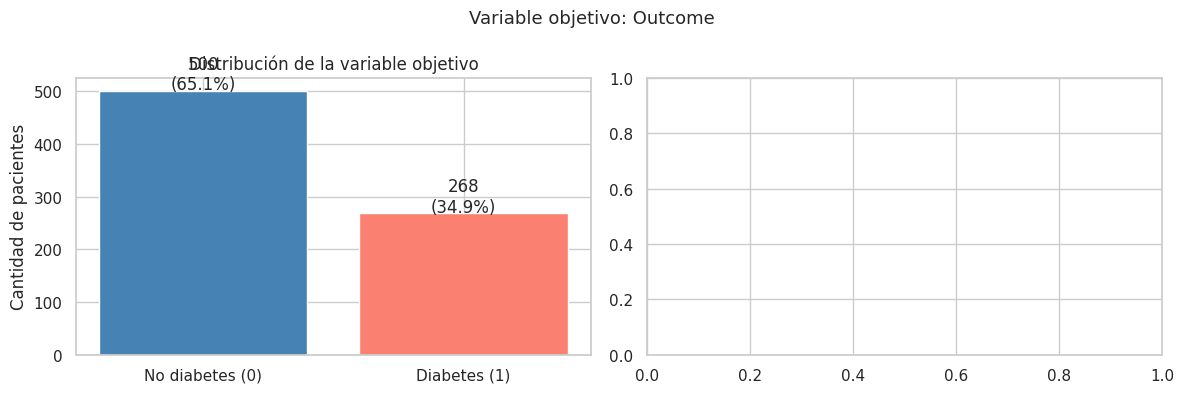

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET].value_counts()
etiquetas = ['No diabetes (0)', 'Diabetes (1)']
axes[0].bar(etiquetas, counts.values, color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Cantidad de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')

plt.suptitle('Variable objetivo: Outcome', fontsize=13)
plt.tight_layout()
plt.show()


### 3.2 Distribución de todas las variables predictoras

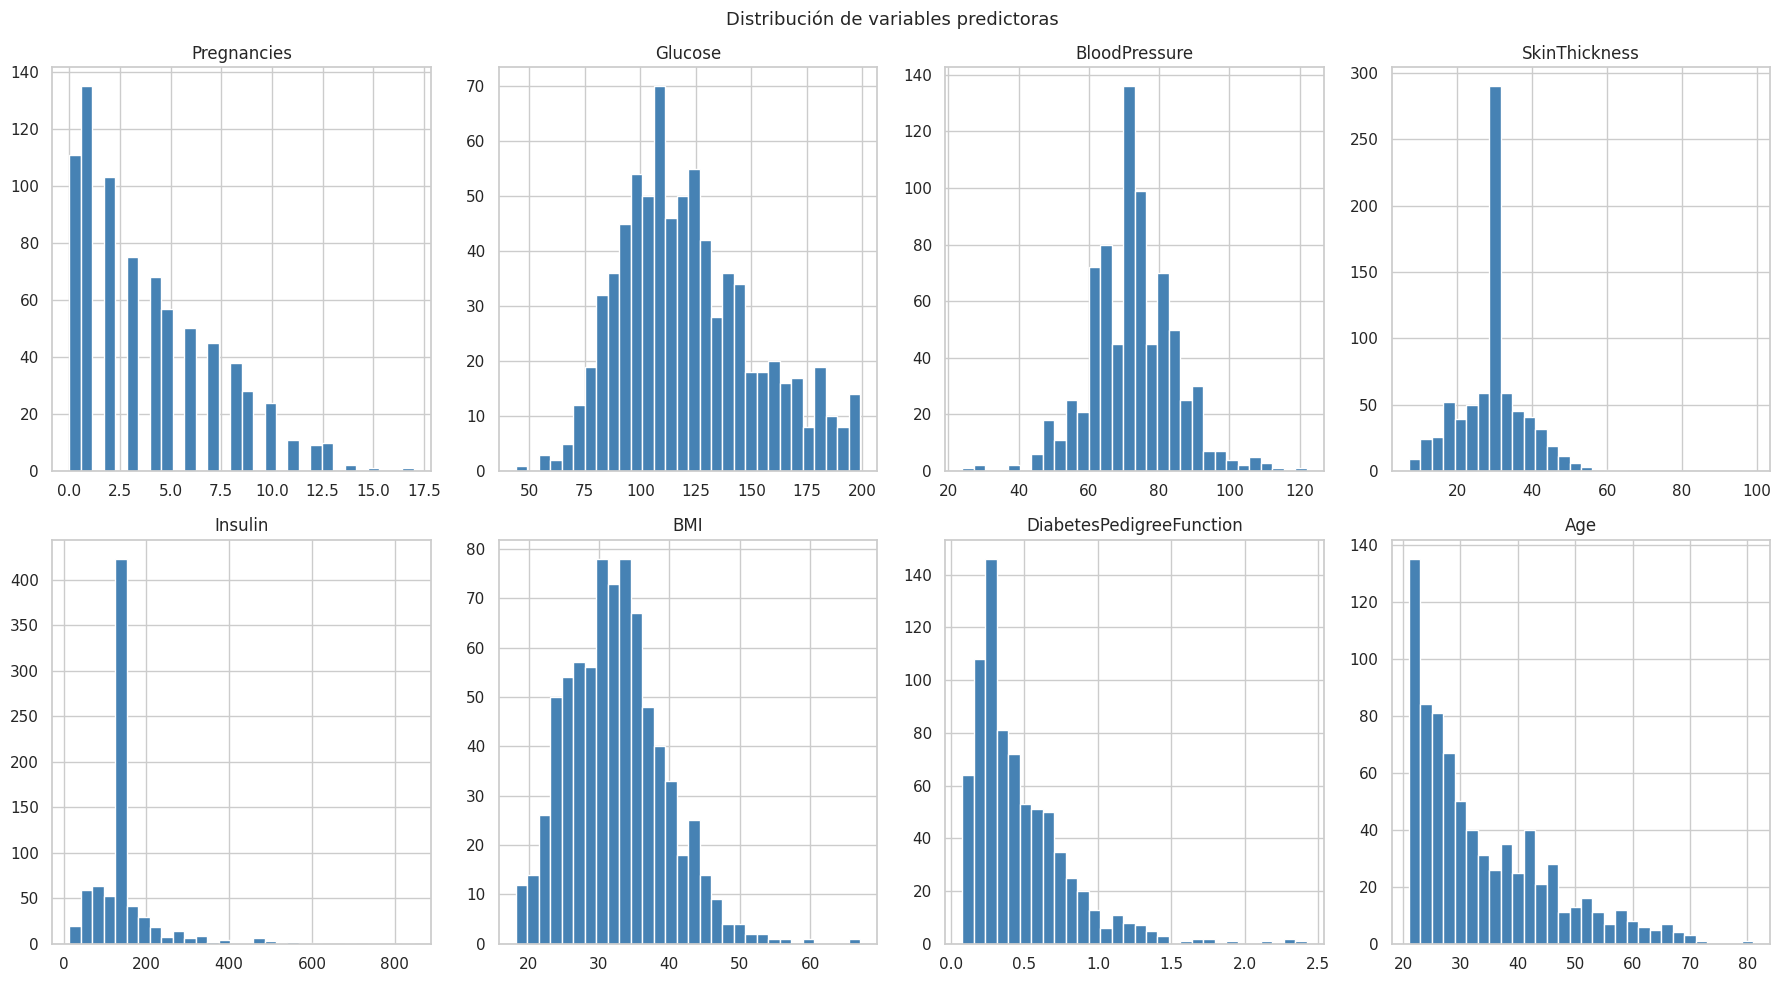

In [11]:
feature_cols = [c for c in df.columns if c != TARGET]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables predictoras', fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Detección de outliers

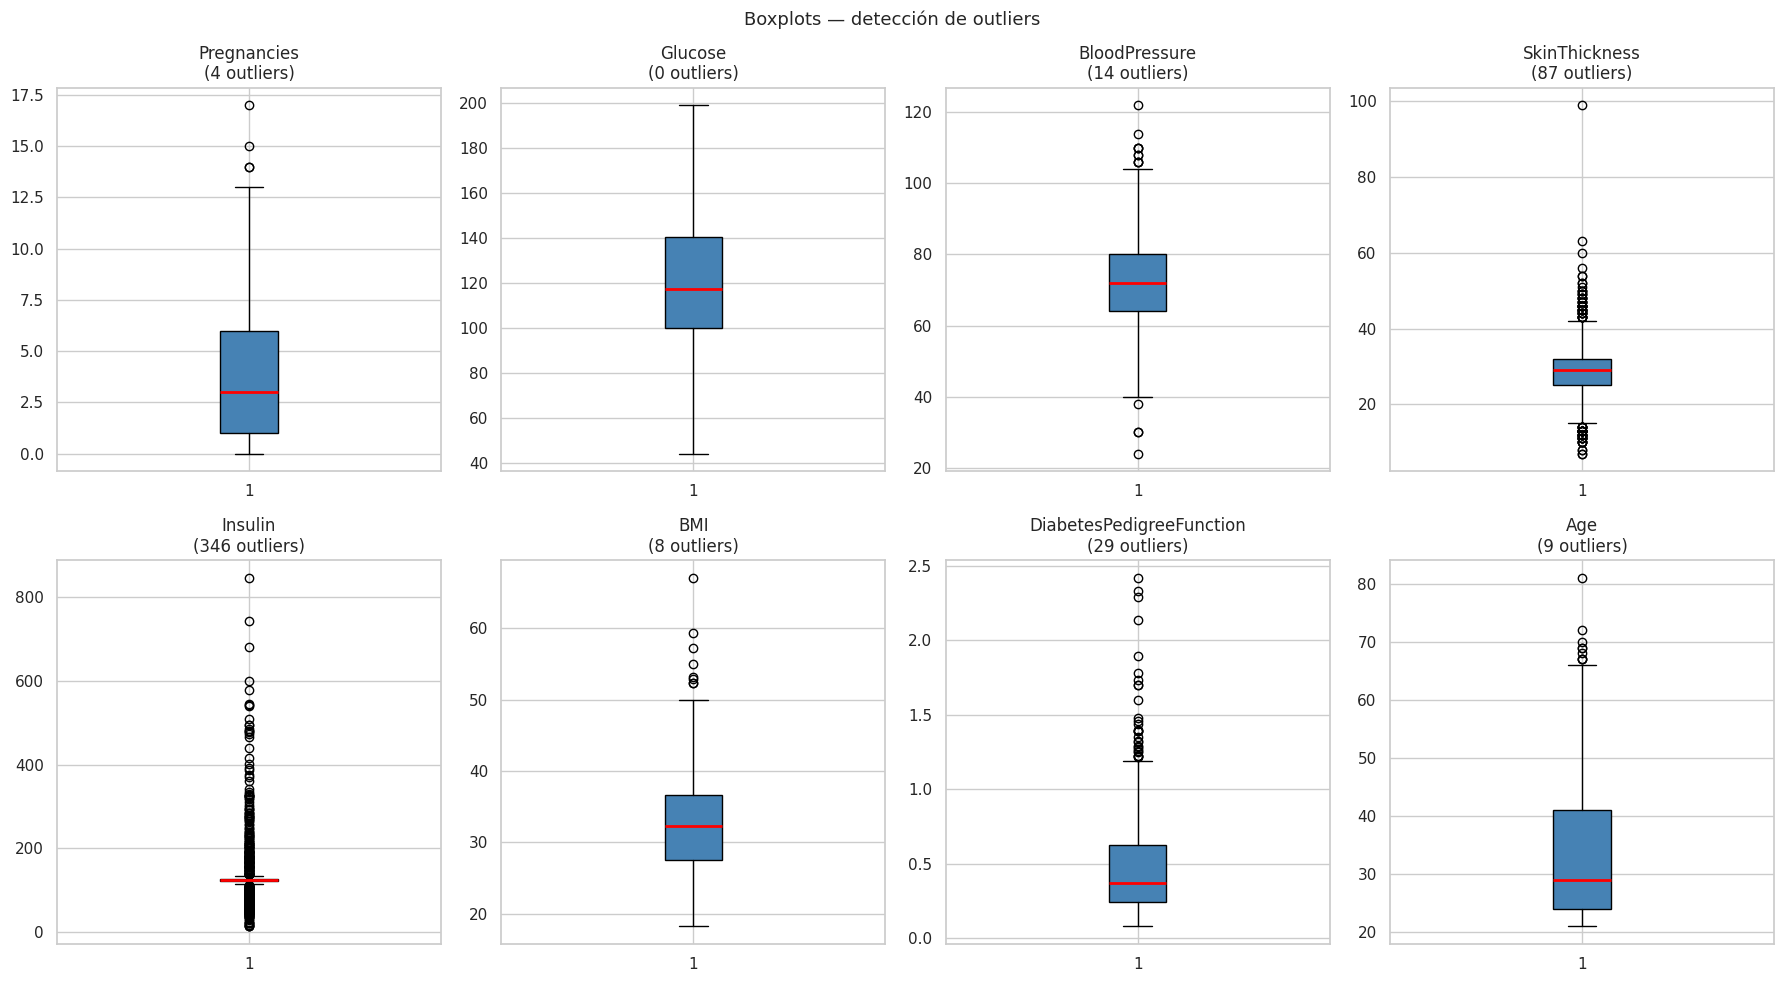

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    axes[i].set_title(f'{col}\n({n_out} outliers)')

plt.suptitle('Boxplots — detección de outliers', fontsize=13)
plt.tight_layout()
plt.show()


## Paso 4: Análisis multivariante

### 4.1 Distribución de cada variable según Outcome


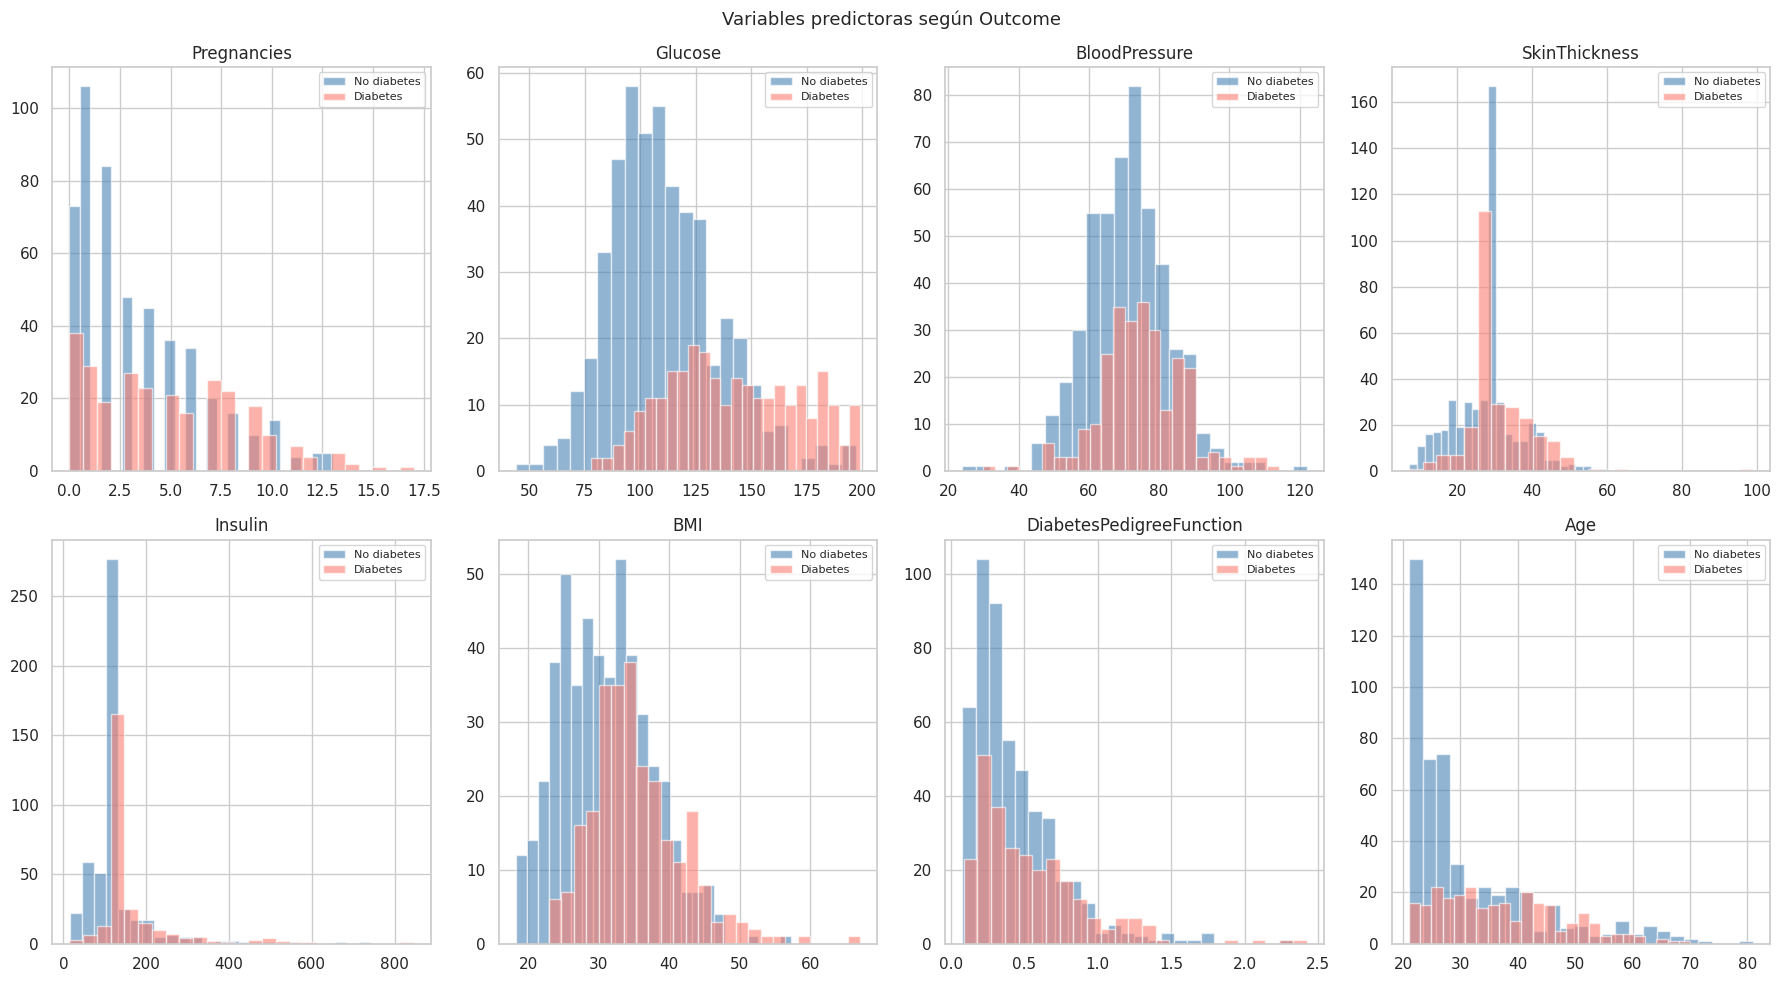

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    no_diab = df[df[TARGET] == 0][col]
    si_diab  = df[df[TARGET] == 1][col]
    axes[i].hist(no_diab, bins=25, alpha=0.6, color='steelblue', label='No diabetes', edgecolor='white')
    axes[i].hist(si_diab,  bins=25, alpha=0.6, color='salmon',    label='Diabetes',    edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Variables predictoras según Outcome', fontsize=13)
plt.tight_layout()
plt.show()


### 4.2 Matriz de correlación

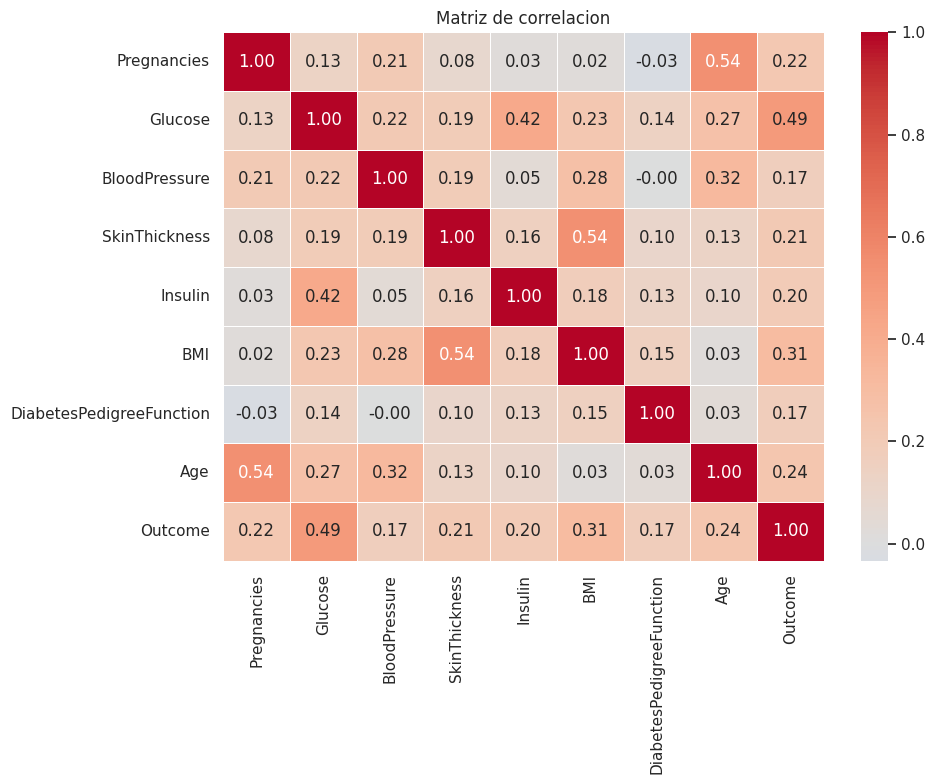

In [14]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.show()


### 4.3 Correlación con la variable objetivo

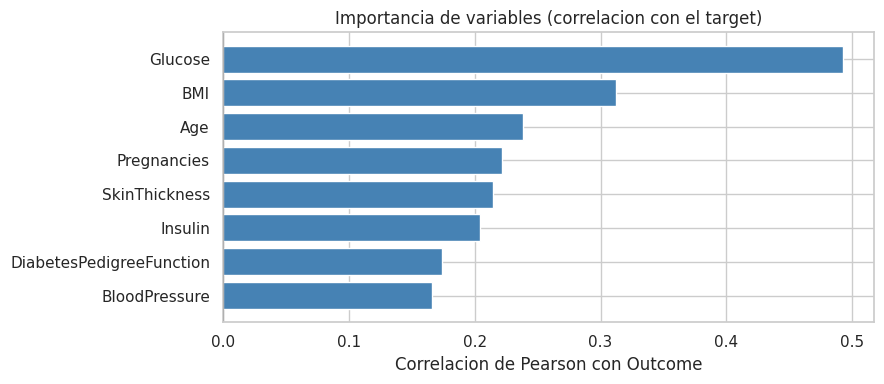

Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166


In [15]:
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

colors = ['steelblue' if v > 0 else 'salmon' for v in corr_target.values]
plt.figure(figsize=(9, 4))
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlacion de Pearson con Outcome')
plt.title('Importancia de variables (correlacion con el target)')
plt.tight_layout()
plt.show()

print(corr_target.round(3).to_string())


## Paso 5: Ingeniería de características

### 5.1 Tratamiento de outliers (clipping IQR)


In [16]:
df_model = df.copy()

for col in feature_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    df_model[col] = df_model[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("Outliers tratados con clipping IQR.")


Outliers tratados con clipping IQR.


## Paso 6: Split train/test y selección de características


In [17]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"% diabetes en train: {y_train.mean()*100:.1f}%")
print(f"% diabetes en test:  {y_test.mean()*100:.1f}%")


X_train: (614, 8)  |  X_test: (154, 8)
% diabetes en train: 34.9%
% diabetes en test:  35.1%


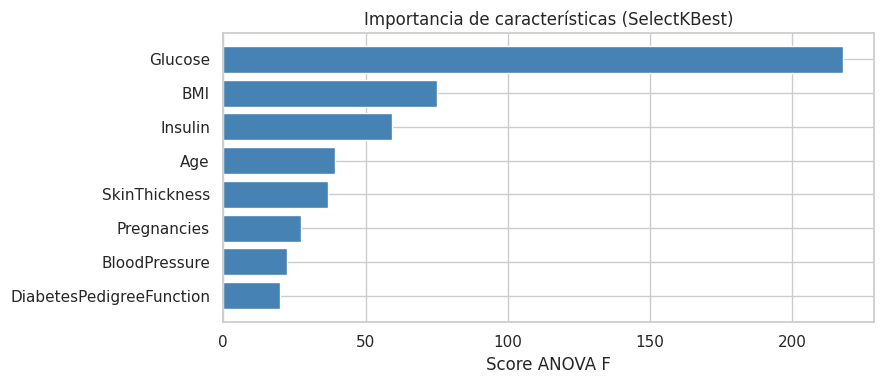

                 feature      score
                 Glucose 217.764822
                     BMI  74.955356
                 Insulin  59.334500
                     Age  39.282445
           SkinThickness  36.699020
             Pregnancies  27.361566
           BloodPressure  22.357287
DiabetesPedigreeFunction  20.037357


In [18]:
# Selección de características con ANOVA F-test
selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores_df = pd.DataFrame({
    'feature': X_train.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

plt.figure(figsize=(9, 4))
plt.barh(scores_df['feature'][::-1], scores_df['score'][::-1], color='steelblue')
plt.xlabel('Score ANOVA F')
plt.title('Importancia de características (SelectKBest)')
plt.tight_layout()
plt.show()

print(scores_df.to_string(index=False))


In [19]:
# Nos quedamos con las 6 mejores
K = 6
selector_k = SelectKBest(f_classif, k=K)
selector_k.fit(X_train, y_train)

ix = selector_k.get_support()
X_train_sel = pd.DataFrame(selector_k.transform(X_train), columns=X_train.columns[ix])
X_test_sel  = pd.DataFrame(selector_k.transform(X_test),  columns=X_test.columns[ix])

print(f"Características seleccionadas (k={K}):")
print(X_train_sel.columns.tolist())


Características seleccionadas (k=6):
['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


## Paso 7: Modelo de árbol de decisión

Los árboles de decisión pueden ser de dos tipos según el problema:
- **DecisionTreeClassifier** → para clasificación (nuestro caso: diabetes sí/no)
- **DecisionTreeRegressor** → para regresión (predecir valores continuos)

Usamos DecisionTreeClassifier porque Outcome es una variable binaria (0/1).

### 7.1 Funciones de pureza de nodos

Los árboles de decisión dividen los datos en cada nodo usando un criterio
de pureza. Existen tres opciones:

| Criterio | Descripción |
|----------|-------------|
| gini | Mide la probabilidad de clasificar mal un elemento aleatorio. Rápido y eficiente. Es el valor por defecto. |
| entropy | Basado en la teoría de la información (información ganada en cada división). Más costoso pero a veces más preciso. |
| log_loss | Similar a entropy pero usando log-loss. Útil cuando se necesitan probabilidades bien calibradas. |

### 7.2 Entrenamiento con los tres criterios


In [20]:
criterios = ['gini', 'entropy', 'log_loss']
resultados = {}

for criterio in criterios:
    arbol = DecisionTreeClassifier(criterion=criterio, random_state=42)
    arbol.fit(X_train_sel, y_train)
    y_pred_c = arbol.predict(X_test_sel)
    
    acc  = accuracy_score(y_test, y_pred_c)
    auc  = roc_auc_score(y_test, arbol.predict_proba(X_test_sel)[:, 1])
    cv   = cross_val_score(arbol, X_train_sel, y_train, cv=5, scoring='accuracy').mean()
    
    resultados[criterio] = {
        'modelo': arbol,
        'y_pred': y_pred_c,
        'accuracy': acc,
        'roc_auc': auc,
        'cv_accuracy': cv
    }
    
    print(f"Criterio: {criterio.upper():<10} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | CV Accuracy: {cv:.4f}")


Criterio: GINI       | Accuracy: 0.6948 | ROC-AUC: 0.6628 | CV Accuracy: 0.6955
Criterio: ENTROPY    | Accuracy: 0.6688 | ROC-AUC: 0.6428 | CV Accuracy: 0.6695
Criterio: LOG_LOSS   | Accuracy: 0.6688 | ROC-AUC: 0.6428 | CV Accuracy: 0.6695


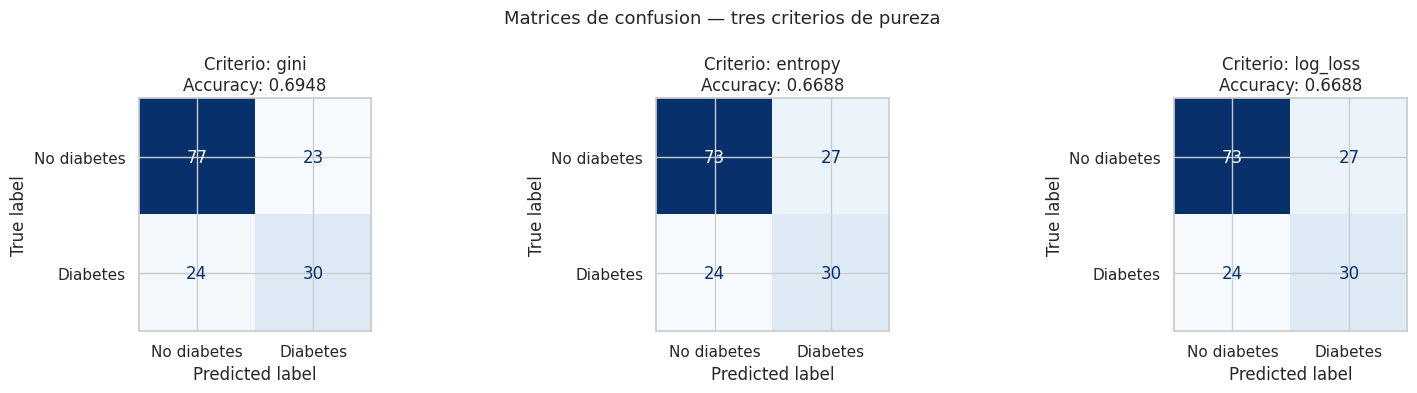

In [21]:
# Matrices de confusion para los tres criterios
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, criterio in enumerate(criterios):
    cm = confusion_matrix(y_test, resultados[criterio]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    acc = resultados[criterio]['accuracy']
    axes[i].set_title(f'Criterio: {criterio}\nAccuracy: {acc:.4f}')

plt.suptitle('Matrices de confusion — tres criterios de pureza', fontsize=13)
plt.tight_layout()
plt.show()


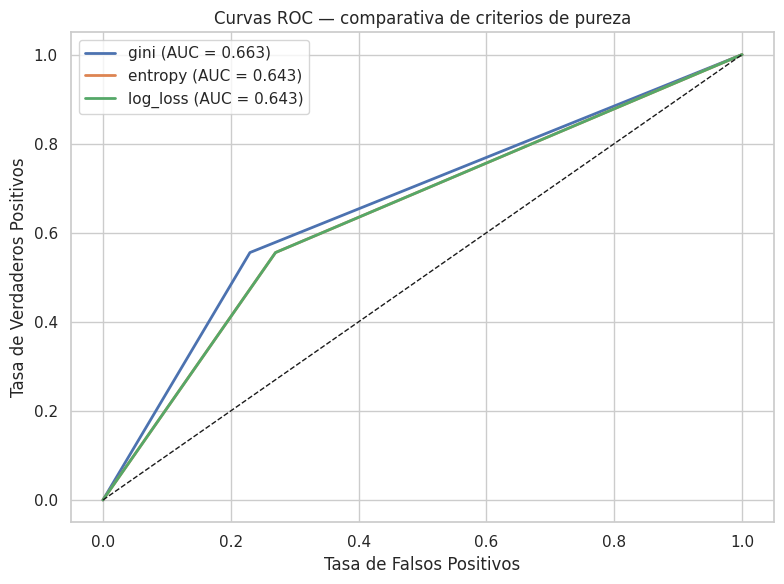

In [22]:
# Curvas ROC para los tres criterios
plt.figure(figsize=(8, 6))

for criterio in criterios:
    modelo = resultados[criterio]['modelo']
    y_prob = modelo.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = resultados[criterio]['roc_auc']
    plt.plot(fpr, tpr, lw=2, label=f'{criterio} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — comparativa de criterios de pureza')
plt.legend()
plt.tight_layout()
plt.show()


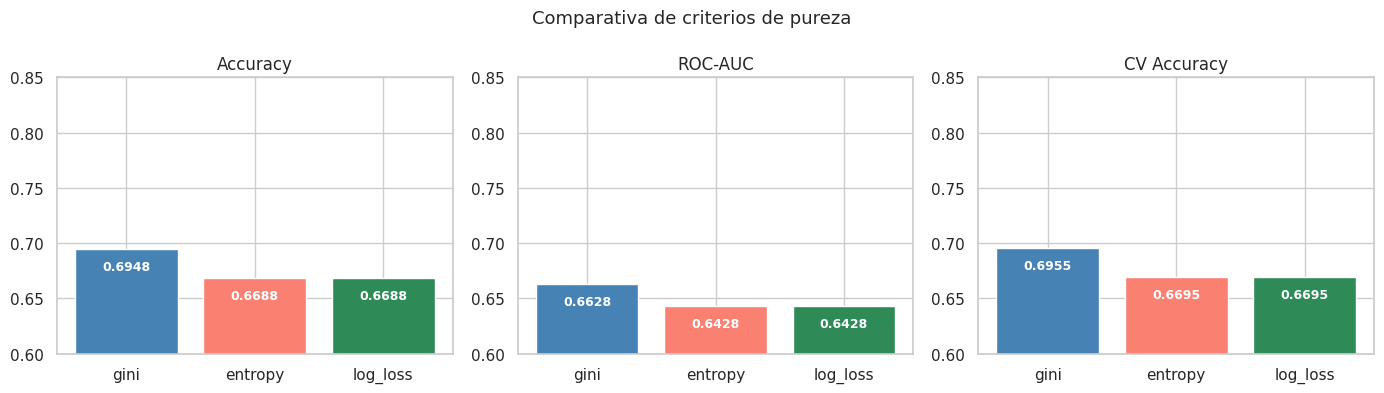

Criterio  Accuracy  ROC-AUC  CV Accuracy
    gini  0.694805 0.662778     0.695495
 entropy  0.668831 0.642778     0.669452
log_loss  0.668831 0.642778     0.669452


In [23]:
# Comparativa visual de métricas
metricas_comp = pd.DataFrame({
    'Criterio': criterios,
    'Accuracy': [resultados[c]['accuracy'] for c in criterios],
    'ROC-AUC':  [resultados[c]['roc_auc'] for c in criterios],
    'CV Accuracy': [resultados[c]['cv_accuracy'] for c in criterios]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores = ['steelblue', 'salmon', 'seagreen']

for i, met in enumerate(['Accuracy', 'ROC-AUC', 'CV Accuracy']):
    bars = axes[i].bar(criterios, metricas_comp[met], color=colores)
    axes[i].set_title(met)
    axes[i].set_ylim(0.6, 0.85)
    for bar, v in zip(bars, metricas_comp[met]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() - 0.01,
                     f'{v:.4f}', ha='center', va='top',
                     color='white', fontweight='bold', fontsize=9)

plt.suptitle('Comparativa de criterios de pureza', fontsize=13)
plt.tight_layout()
plt.show()

print(metricas_comp.to_string(index=False))


Mejor criterio segun ROC-AUC: gini


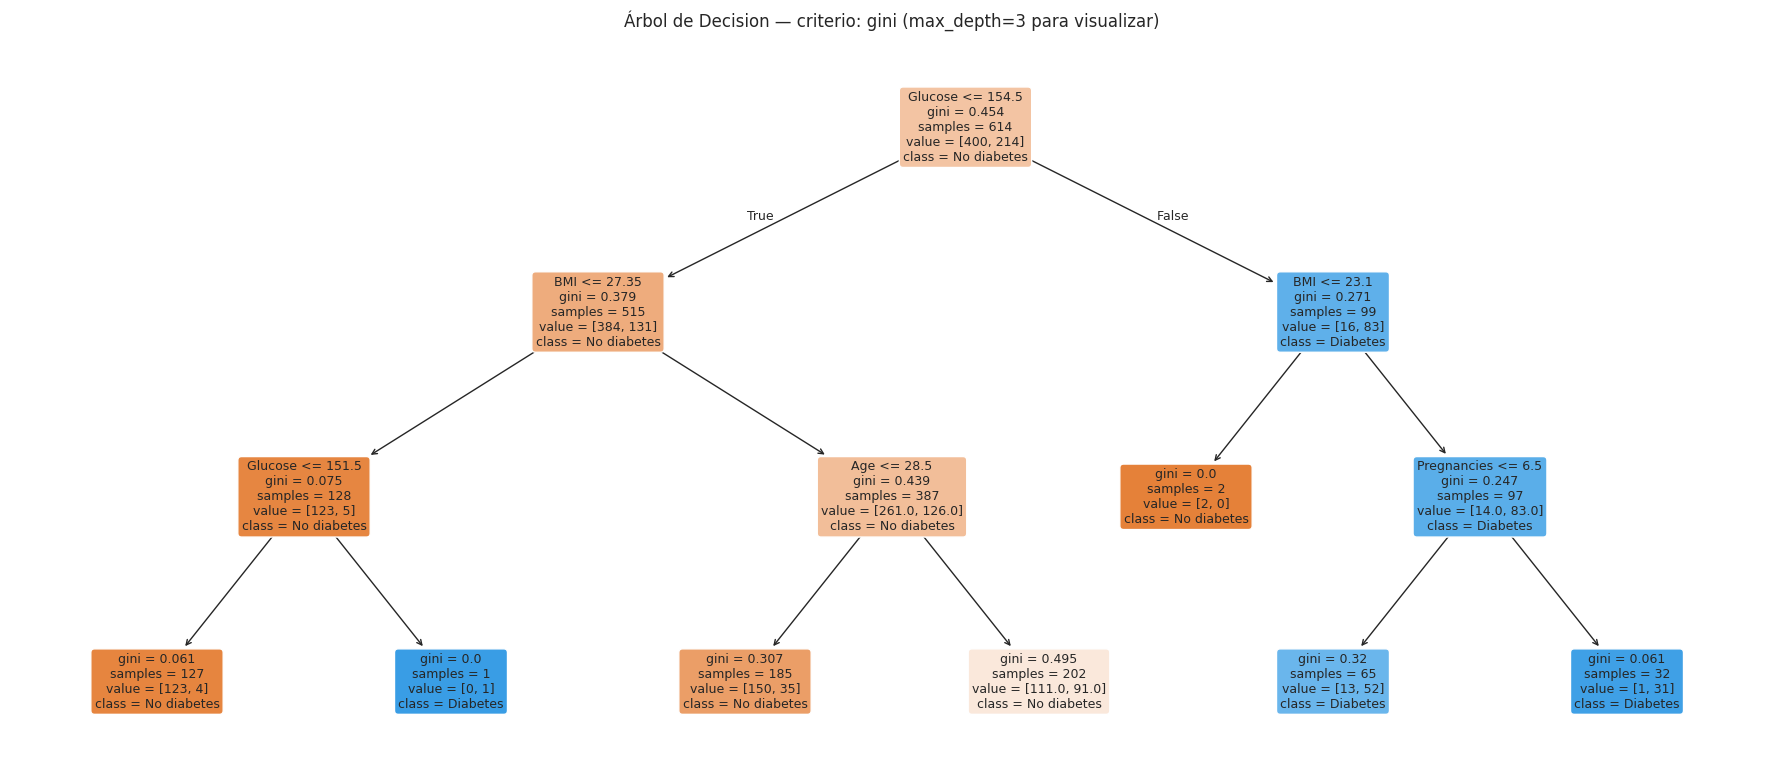

In [24]:
# Visualizacion del arbol (criterio gini - primeros 3 niveles)
mejor_criterio = metricas_comp.sort_values('ROC-AUC', ascending=False).iloc[0]['Criterio']
print(f"Mejor criterio segun ROC-AUC: {mejor_criterio}")

arbol_viz = DecisionTreeClassifier(criterion=mejor_criterio, max_depth=3, random_state=42)
arbol_viz.fit(X_train_sel, y_train)

plt.figure(figsize=(18, 8))
plot_tree(arbol_viz, feature_names=X_train_sel.columns.tolist(),
          class_names=['No diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=9)
plt.title(f'Árbol de Decision — criterio: {mejor_criterio} (max_depth=3 para visualizar)')
plt.tight_layout()
plt.show()


## Paso 8: Optimización con Grid Search

Seleccionamos el mejor criterio y optimizamos todos los hiperparámetros
con **GridSearchCV** y validación cruzada de 5 folds.


In [25]:
# Definimos la cuadrícula de hiperparámetros
param_grid = {
    'criterion':         [mejor_criterio],
    'max_depth':         [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', None]
}

arbol_base = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    arbol_base,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sel, y_train)

print(f"\nMejores hiperparámetros:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor ROC-AUC (CV): {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 336 candidates, totalling 1680 fits



Mejores hiperparámetros:
  criterion: gini
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 8
  min_samples_split: 20

Mejor ROC-AUC (CV): 0.7830


In [26]:
# Evaluacion del modelo optimizado
mejor_arbol = grid_search.best_estimator_
y_pred_opt  = mejor_arbol.predict(X_test_sel)
y_prob_opt  = mejor_arbol.predict_proba(X_test_sel)[:, 1]

acc_opt = accuracy_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_prob_opt)

print("=" * 55)
print("RESULTADOS — Árbol Optimizado (Grid Search)")
print("=" * 55)
print(f"  Accuracy : {acc_opt:.4f}")
print(f"  ROC-AUC  : {auc_opt:.4f}")
print()
print(classification_report(y_test, y_pred_opt,
      target_names=['No diabetes', 'Diabetes']))


RESULTADOS — Árbol Optimizado (Grid Search)
  Accuracy : 0.7273
  ROC-AUC  : 0.7525

              precision    recall  f1-score   support

 No diabetes       0.82      0.75      0.78       100
    Diabetes       0.60      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



                  Modelo  Accuracy  ROC-AUC
             Base (gini)    0.6948   0.6628
Optimizado (Grid Search)    0.7273   0.7525


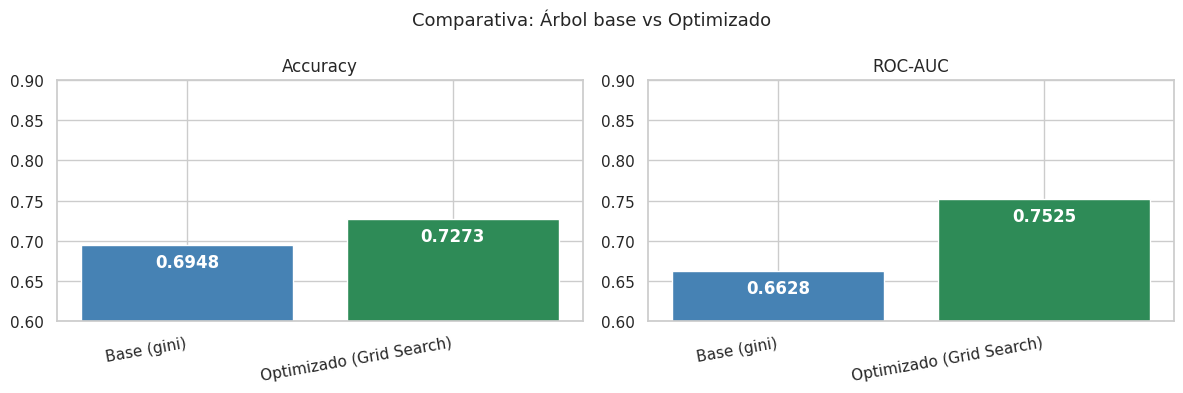

In [27]:
# Comparativa final: modelo base vs optimizado
acc_base = resultados[mejor_criterio]['accuracy']
auc_base = resultados[mejor_criterio]['roc_auc']

resumen = pd.DataFrame({
    'Modelo': [f'Base ({mejor_criterio})', 'Optimizado (Grid Search)'],
    'Accuracy': [round(acc_base, 4), round(acc_opt, 4)],
    'ROC-AUC':  [round(auc_base, 4), round(auc_opt, 4)]
})
print(resumen.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['steelblue', 'seagreen']

for i, met in enumerate(['Accuracy', 'ROC-AUC']):
    bars = axes[i].bar(resumen['Modelo'], resumen[met], color=colores)
    axes[i].set_title(met)
    axes[i].set_ylim(0.6, 0.9)
    axes[i].set_xticklabels(resumen['Modelo'], rotation=10, ha='right')
    for bar, v in zip(bars, resumen[met]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() - 0.01,
                     f'{v:.4f}', ha='center', va='top',
                     color='white', fontweight='bold')

plt.suptitle('Comparativa: Árbol base vs Optimizado', fontsize=13)
plt.tight_layout()
plt.show()


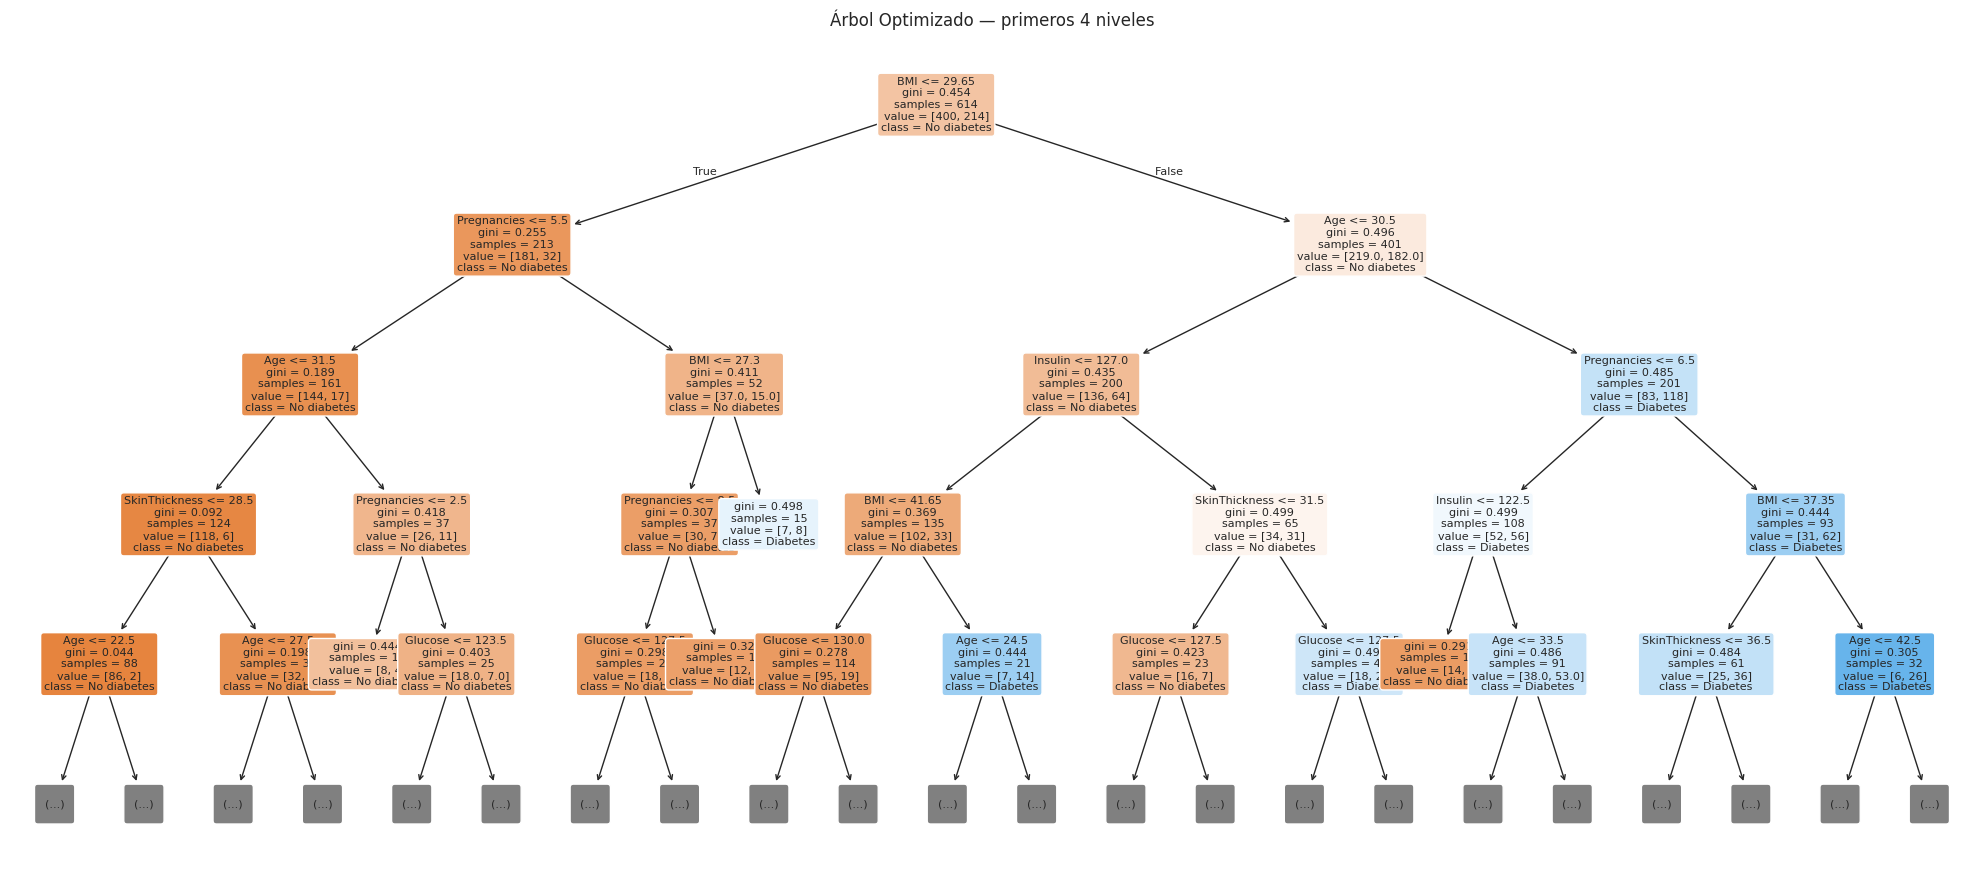

In [28]:
# Visualizacion del arbol optimizado (limitado a 4 niveles para legibilidad)
plt.figure(figsize=(20, 9))
plot_tree(mejor_arbol,
          feature_names=X_train_sel.columns.tolist(),
          class_names=['No diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=8,
          max_depth=4)
plt.title('Árbol Optimizado — primeros 4 niveles')
plt.tight_layout()
plt.show()


In [29]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Unimos X e y para guardar como CSV completo
train_data = X_train_sel.copy()
train_data["Outcome"] = y_train.values

test_data = X_test_sel.copy()
test_data["Outcome"] = y_test.values

train_data.to_csv("../data/processed/train_data.csv", index=False)
test_data.to_csv("../data/processed/test_data.csv",   index=False)

print("✅ train_data.csv guardado")
print("✅ test_data.csv guardado")
print(f"   Train shape: {train_data.shape}")
print(f"   Test shape:  {test_data.shape}")

✅ train_data.csv guardado
✅ test_data.csv guardado
   Train shape: (614, 7)
   Test shape:  (154, 7)


## Paso 9: Guardado del modelo

In [30]:
import os

# Creamos la carpeta models si no existe
os.makedirs('../models', exist_ok=True)

# Guardamos el modelo optimizado
ruta_modelo = '../models/decision_tree_diabetes.pkl'
joblib.dump(mejor_arbol, ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

# Verificamos que se puede cargar correctamente
modelo_cargado = joblib.load(ruta_modelo)
y_test_check   = modelo_cargado.predict(X_test_sel)
print(f" Modelo cargado y verificado. Accuracy: {accuracy_score(y_test, y_test_check):.4f}")


Modelo guardado en: ../models/decision_tree_diabetes.pkl
 Modelo cargado y verificado. Accuracy: 0.7273


In [31]:
# Guardamos también el selector de características para usar en produccion
ruta_selector = '../models/feature_selector_diabetes.pkl'
joblib.dump(selector_k, ruta_selector)
print(f"Selector de características guardado en: {ruta_selector}")
print(f"   Características usadas: {X_train_sel.columns.tolist()}")


Selector de características guardado en: ../models/feature_selector_diabetes.pkl
   Características usadas: ['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


## Conclusiones

**Tratamiento de datos:** El dataset tenía ceros en
variables como Glucose, BloodPressure o BMI, que fueron reemplazados
por la mediana de cada columna antes de entrenar.

**Variables más importantes:** Glucose y BMI son las más correlacionadas
con el diagnóstico de diabetes, seguidas de Age y DiabetesPedigreeFunction.

Los tres criterios dan resultados muy similares en este dataset, lo que
indica que la estructura de los datos es clara y el árbol la captura
bien independientemente del criterio.

**Optimización con Grid Search:** Al ajustar max_depth, min_samples_split
y min_samples_leaf se reduce el sobreajuste del árbol base (que sin límites
memoriza los datos de entrenamiento) y mejora la generalización en test.

